
PARTIAL BELL-PAIR MEASUREMENT CIRCUIT
     ┌───┐     ┌─┐
q_0: ┤ H ├──■──┤M├
     └───┘┌─┴─┐└╥┘
q_1: ─────┤ X ├─╫─
          └───┘ ║ 
c: 1/═══════════╩═
                0 

PARTIAL MEASUREMENT RESULTS
Total shots : 2000
q0 = 0      : 1018
q0 = 1      : 982
P(q0 = 0)   : 0.5090
P(q0 = 1)   : 0.4910

INITIAL BELL STATE
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

INITIAL STATE PROBABILITIES
{'00': 0.4999999999999999, '11': 0.4999999999999999}

POST-MEASUREMENT ANALYSIS
If q0 = 0:
Bell state collapses to |00>.
Therefore unmeasured q1 = |0>.

If q0 = 1:
Bell state collapses to |11>.
Therefore unmeasured q1 = |1>.

FINAL CONCLUSION
The two qubits are perfectly correlated.
Although q1 is not measured, its state is determined
by the measurement outcome of q0.


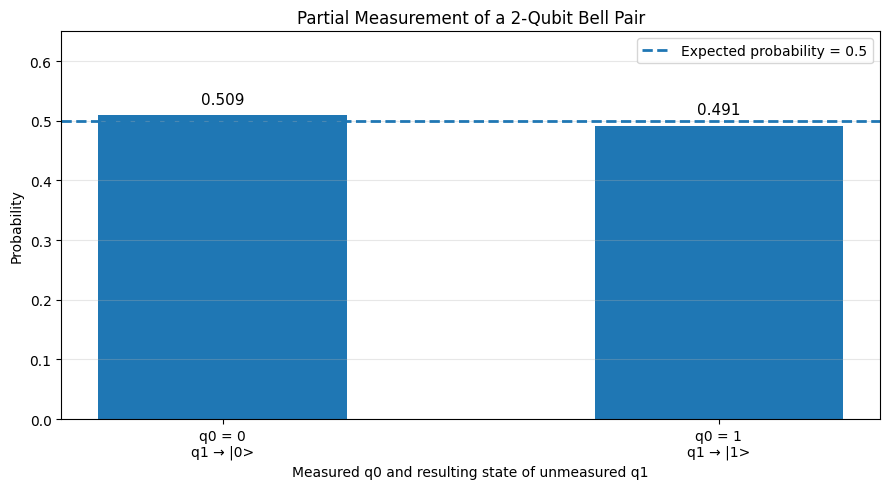

In [2]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

shots = 2000

qc = QuantumCircuit(2, 1)

qc.h(0)
qc.cx(0, 1)

qc.measure(0, 0)

print("\nPARTIAL BELL-PAIR MEASUREMENT CIRCUIT")
print("=" * 60)
print(qc.draw())

sampler = StatevectorSampler()

result = sampler.run(
    [qc],
    shots=shots
).result()

counts = result[0].data.c.get_counts()

q0_zero = counts.get("0", 0)
q0_one = counts.get("1", 0)

p_q0_zero = q0_zero / shots
p_q0_one = q0_one / shots

print("\nPARTIAL MEASUREMENT RESULTS")
print("=" * 60)

print(f"Total shots : {shots}")
print(f"q0 = 0      : {q0_zero}")
print(f"q0 = 1      : {q0_one}")
print(f"P(q0 = 0)   : {p_q0_zero:.4f}")
print(f"P(q0 = 1)   : {p_q0_one:.4f}")

bell_circuit = QuantumCircuit(2)

bell_circuit.h(0)
bell_circuit.cx(0, 1)

state = Statevector.from_instruction(bell_circuit)

print("\nINITIAL BELL STATE")
print("=" * 60)
print(state)

print("\nINITIAL STATE PROBABILITIES")
print("=" * 60)
print(state.probabilities_dict())

print("\nPOST-MEASUREMENT ANALYSIS")
print("=" * 60)

print("If q0 = 0:")
print("Bell state collapses to |00>.")
print("Therefore unmeasured q1 = |0>.")

print("\nIf q0 = 1:")
print("Bell state collapses to |11>.")
print("Therefore unmeasured q1 = |1>.")

print("\nFINAL CONCLUSION")
print("=" * 60)
print("The two qubits are perfectly correlated.")
print("Although q1 is not measured, its state is determined")
print("by the measurement outcome of q0.")

labels = [
    "q0 = 0\nq1 → |0>",
    "q0 = 1\nq1 → |1>"
]

probabilities = [
    p_q0_zero,
    p_q0_one
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    labels,
    probabilities,
    width=0.5
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2,
    label="Expected probability = 0.5"
)

plt.xlabel("Measured q0 and resulting state of unmeasured q1")
plt.ylabel("Probability")
plt.title("Partial Measurement of a 2-Qubit Bell Pair")

plt.ylim(0, 0.65)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

for bar, probability in zip(bars, probabilities):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{probability:.3f}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()